## Import Packages

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, recall_score, accuracy_score, f1_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn import set_config

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
set_config(transform_output='pandas')

print('All core packages imported successfully.')

All core packages imported successfully.


In [ ]:
try:
    import dagshub
    dagshub.init(repo_owner='Ankitkumar1141', repo_name='Churn-modelling', mlflow=True)
    print('DagsHub initialized successfully.')
except Exception as e:
    print(f'[DagsHub Notice] {e}')

Accessing as Ankitkumar1141

Initialized MLflow to track repo "Ankitkumar1141/Churn-modelling"

Repository Ankitkumar1141/Churn-modelling initialized!

DagsHub initialized successfully.


In [ ]:
try:
    import mlflow
    mlflow.set_tracking_uri('https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow')
    mlflow.set_experiment('Experiment 3 - Class Imbalance Handling')
    print('MLflow tracking active on DagsHub.')
except Exception as e:
    print(f'[MLflow Notice] {e}')

2026/09/28 14:51:19 INFO mlflow.tracking.fluent: Experiment with name 'Experiment 3 - Class Imbalance Handling' does not exist. Creating a new experiment.


MLflow tracking active on DagsHub.


## Load the Preprocessed Data

In [ ]:

df = pd.read_csv("preprocessed.csv")
print('Loaded dataset shape:', df.shape)
df.head(3)

Loaded dataset shape: (10000, 37)


,customer_id,name,gender,age,salary,location_id,churned,account_id,tenure,balance,...,is_single_product,inactive_senior,engagement_score,high_risk_inactive,is_female,geo_france,geo_germany,geo_spain,geo_uk,geo_usa
0,15634602,Hargrave,female,42,101348.88,2,1,A15634602SID,2,NaN,...,1,0,0.750000,0,1,1,0,0,0,0
1,15647311,Hill,female,41,112542.58,6,0,A15647311SID,1,83807.86,...,1,0,0.416667,0,1,0,0,0,0,1
2,15619304,Onio,female,42,113931.57,4,1,A15619304SID,8,159660.80,...,0,0,0.583333,0,1,0,0,0,1,0


## Exploratory Checks

In [ ]:
df.dtypes

customer_id                  int64
name                        object
gender                      object
age                          int64
salary                     float64
location_id                  int64
churned                      int64
account_id                  object
tenure                       int64
balance                    float64
num_products                 int64
has_credit_card              int64
is_active                    int64
geography                   object
age_group                   object
salary_bracket              object
tenure_group                object
has_balance                  int64
churn_label                 object
has_credit_card_label       object
is_active_label             object
balance_to_salary          float64
balance_per_product        float64
age_when_joined              int64
products_per_tenure        float64
is_senior_risk               int64
is_extreme_product_risk      int64
is_single_product            int64
inactive_senior     

In [ ]:
df.isna().sum().sort_values(ascending=False).head(5)

balance        3617
name              0
gender            0
age               0
customer_id       0
dtype: int64

In [ ]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


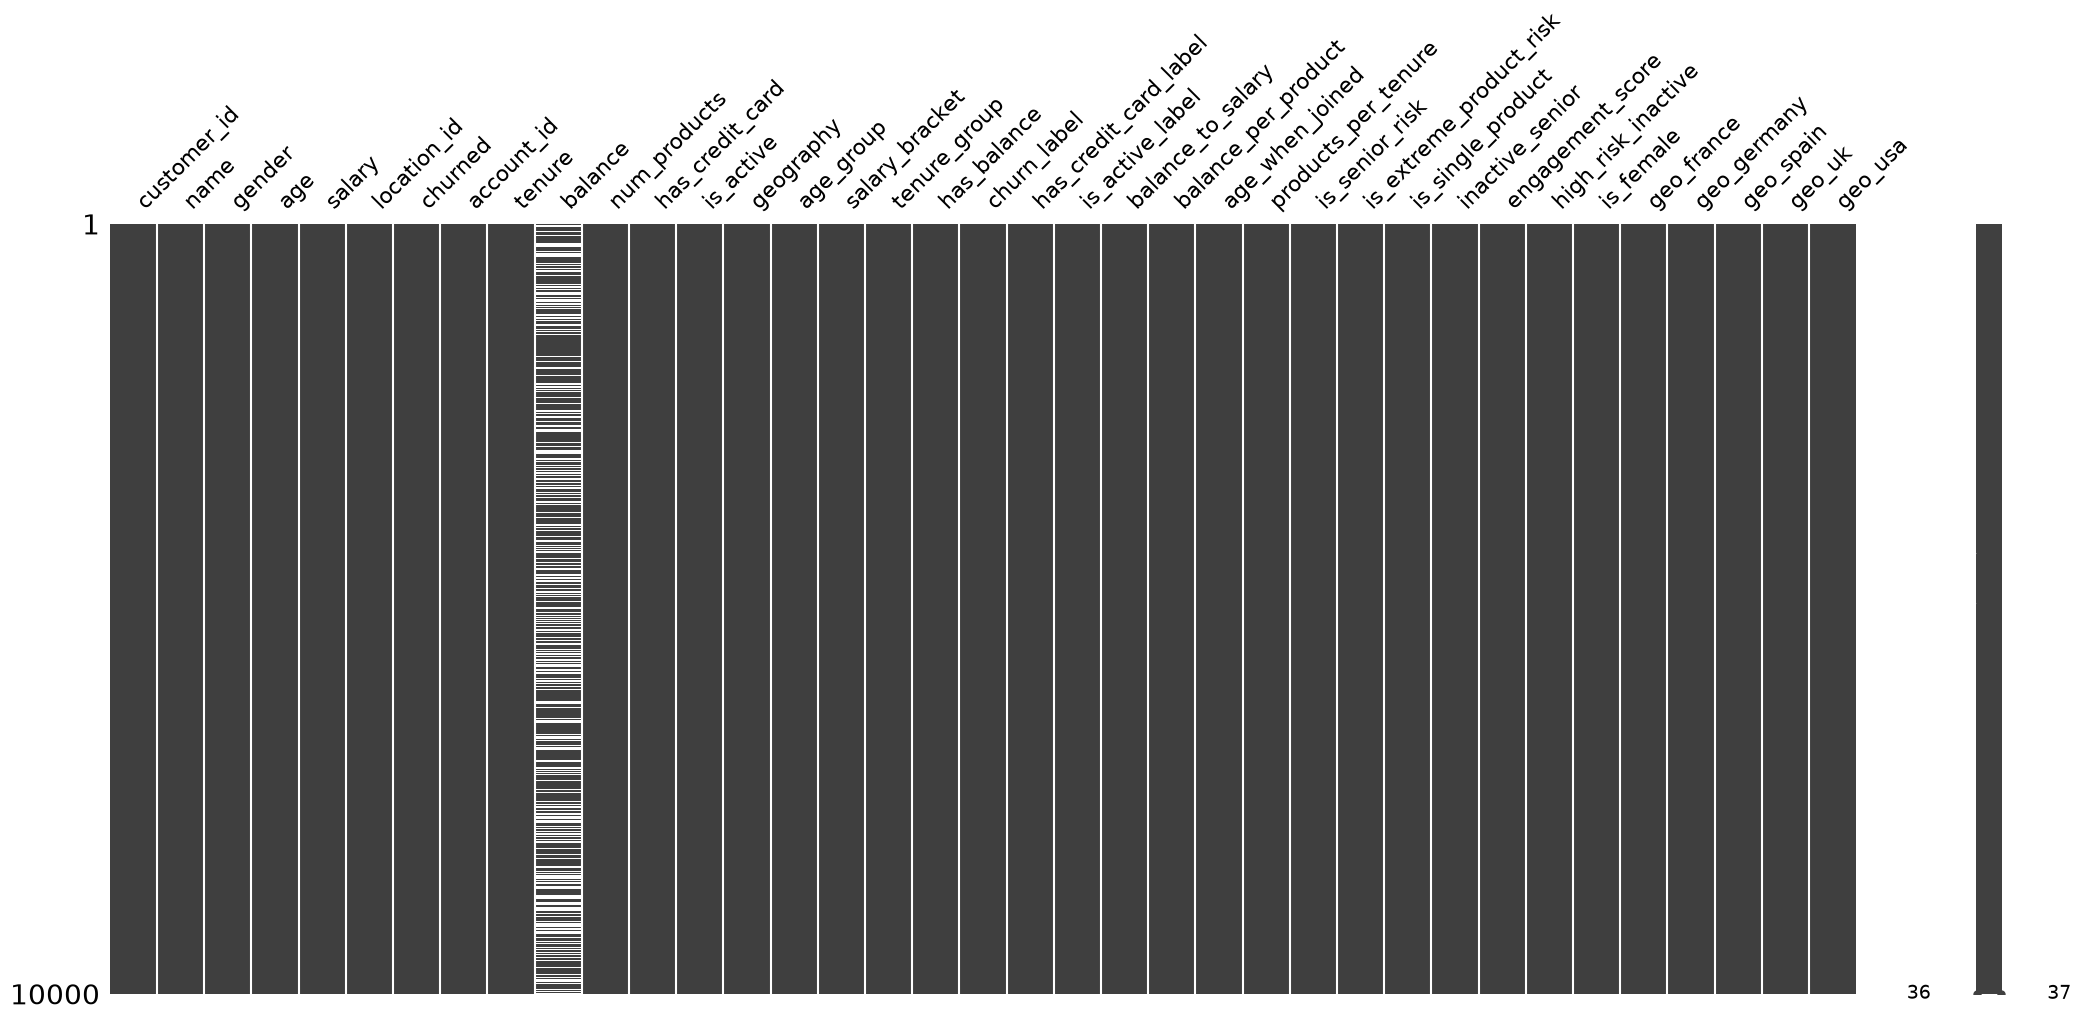

In [ ]:
# Missing-value visualization -- only Balance has nulls (36.17%)
msno.matrix(df)
plt.tight_layout()
plt.show()

churned
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


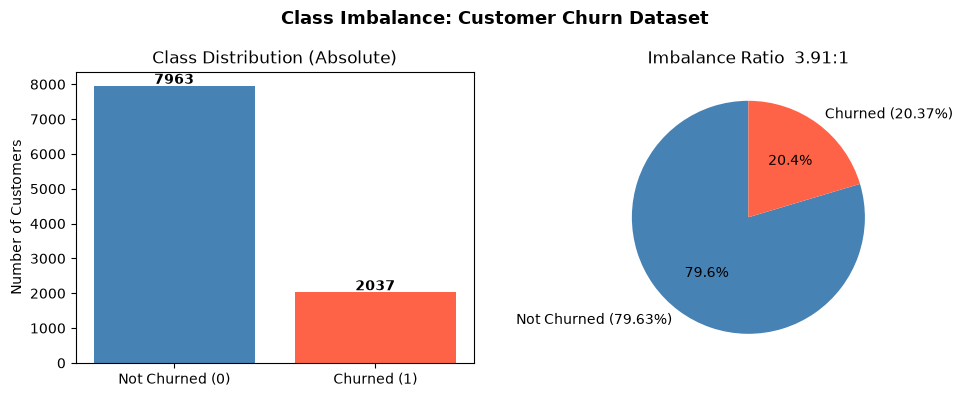

In [ ]:
print(df['churned'].value_counts())
churn_rate = df['churned'].mean()
print('\nChurn rate: {:.2%}'.format(churn_rate))

# Visualise class imbalance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df['churned'].value_counts()
axes[0].bar(['Not Churned (0)', 'Churned (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution (Absolute)')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[1].pie(
    counts.values,
    labels=['Not Churned (79.63%)', 'Churned (20.37%)'],
    colors=['steelblue', 'tomato'],
    autopct='%1.1f%%',
    startangle=90,
)
axes[1].set_title('Imbalance Ratio  3.91:1')
plt.suptitle('Class Imbalance: Customer Churn Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Drop Unnecessary Columns

In [ ]:
drop_columns = [
    'has_balance',
    'products_per_tenure',
    'has_credit_card',
    'geo_france', 'geo_uk', 'geo_usa', 'geo_spain', 'geo_germany',
    'tenure', 'salary',
    'customer_id',
    'account_id', 'name', 'location_id',
    'age_when_joined', 'age',
    'churn_label',
    'has_credit_card_label',
    'is_active_label',
]

df = df.drop(columns=drop_columns)
print('Shape after dropping columns:', df.shape)
df.head(3)

Shape after dropping columns: (10000, 18)


,gender,churned,balance,num_products,is_active,geography,age_group,salary_bracket,tenure_group,balance_to_salary,balance_per_product,is_senior_risk,is_extreme_product_risk,is_single_product,inactive_senior,engagement_score,high_risk_inactive,is_female
0,female,1,NaN,1,1,france,36-45,high,new (0-2),0.000000,0.000000,0,0,1,0,0.750000,0,1
1,female,0,83807.86,1,1,usa,36-45,high,new (0-2),0.744670,83807.860000,0,0,1,0,0.416667,0,1
2,female,1,159660.80,3,0,uk,36-45,high,veteran (8-10),1.401362,53220.266667,0,1,0,0,0.583333,0,1


In [ ]:
missing_cols = df.isna().any(axis=0).loc[lambda x: x].index.tolist()
print('Columns with missing values:', missing_cols)
pct_missing_rows = df.isna().any(axis=1).mean().round(4) * 100
print(f'Rows with missing values: {pct_missing_rows:.2f}%  ({df.isna().any(axis=1).sum():,} rows)')

Columns with missing values: ['balance']
Rows with missing values: 36.17%  (3,617 rows)


In [ ]:
X = df.drop(columns='churned')
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print('Train size : {:,}  |  churn rate: {:.2%}'.format(X_train.shape[0], y_train.mean()))
print('Test  size : {:,}  |  churn rate: {:.2%}'.format(X_test.shape[0], y_test.mean()))

Train size : 8,000  |  churn rate: 20.38%
Test  size : 2,000  |  churn rate: 20.35%


In [ ]:
print('Train shape:', X_train.shape)
print('Test  shape:', X_test.shape)
print('Missing in train (balance only):\n', X_train.isna().sum()[X_train.isna().sum() > 0])

Train shape: (8000, 17)
Test  shape: (2000, 17)
Missing in train (balance only):
 balance    2891
dtype: int64


## Column Type Identification

In [ ]:
numeric_cols     = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
binary_cols      = [c for c in numeric_cols if X[c].nunique() == 2]
scale_cols       = [c for c in numeric_cols if c not in binary_cols]

print('Numeric (to scale) :', scale_cols)
print('Binary pass-thru   :', binary_cols)
print('Categorical OHE    :', categorical_cols)

Numeric (to scale) : ['balance', 'num_products', 'balance_to_salary', 'balance_per_product', 'engagement_score']
Binary pass-thru   : ['is_active', 'is_senior_risk', 'is_extreme_product_risk', 'is_single_product', 'inactive_senior', 'high_risk_inactive', 'is_female']
Categorical OHE    : ['gender', 'geography', 'age_group', 'salary_bracket', 'tenure_group']


### Preprocessing Pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scale',          MinMaxScaler(), scale_cols),
        ('nominal_encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False,
)
preprocessor.set_output(transform='pandas')

knn_imputer = KNNImputer(n_neighbors=10)

# Sanity check -- fit on train, transform test using flat steps
base_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('knn_imputer',  knn_imputer),
])
X_train_trans = base_pipeline.fit_transform(X_train)
X_test_trans  = base_pipeline.transform(X_test)

print('X_train transformed shape:', X_train_trans.shape)
print('X_test  transformed shape:', X_test_trans.shape)

X_train transformed shape: (8000, 28)
X_test  transformed shape: (2000, 28)


##  Imbalance class Benchmark

8 strategies benchmarked with a fixed `RandomForestClassifier(random_state=42)` base estimator  
using **5-Fold Stratified Cross-Validation** and **Recall as the primary business metric**.  

| # | Strategy | Technique |
|---|---|---|
| A | Baseline | No resampling, standard weights |
| B | Cost-Sensitive | `class_weight='balanced'` |
| C | Random Under-Sampling | Majority class downsampled to match minority |
| D | Random Over-Sampling | Minority class duplicated to match majority |
| E | SMOTE | Synthetic minority oversampling |
| F | ADASYN | Adaptive synthetic sampling (density-weighted) |
| G | SMOTE + Tomek | Synthetic oversampling + boundary cleaning |
| H | SMOTE + Class Weights | Hybrid: synthesis + cost weighting |

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc'  : 'roc_auc',
    'recall'   : 'recall',
    'precision': 'precision',
    'f1'       : 'f1',
    'accuracy' : 'accuracy',
}

In [ ]:
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

def run_experiment(run_name, sampler=None, class_weight=None):
    """
    Train a RandomForestClassifier with specified imbalance strategy.
    Uses a flat ImbPipeline to avoid nested pipeline issues with imblearn.
    Logs metrics to MLflow on DagsHub (if available).
    """
    rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight=class_weight)

    steps = [
        ('preprocessor', preprocessor),
        ('knn_imputer',  KNNImputer(n_neighbors=10)),
    ]
    if sampler is not None:
        from imblearn.pipeline import Pipeline as ImbPipeline
        steps.append(('sampler', sampler))
        steps.append(('classifier', rf))
        model_pipe = ImbPipeline(steps=steps)
    else:
        from sklearn.pipeline import Pipeline
        steps.append(('classifier', rf))
        model_pipe = Pipeline(steps=steps)

    # 5-Fold Stratified Cross-Validation on raw X_train (pipeline handles imputation inside each fold)
    cv_results = cross_validate(
        model_pipe, X_train, y_train,
        cv=cv, scoring=scoring,
        return_train_score=False, n_jobs=1,
    )
    results_df = pd.DataFrame(cv_results)

    # Fit on full training set for hold-out evaluation
    model_pipe.fit(X_train, y_train)
    y_pred_train = model_pipe.predict(X_train)
    y_pred_test  = model_pipe.predict(X_test)
    y_prob_train = model_pipe.predict_proba(X_train)[:, 1]
    y_prob_test  = model_pipe.predict_proba(X_test)[:, 1]

    metrics = {
        'training_accuracy' : accuracy_score(y_train, y_pred_train),
        'training_recall'   : recall_score(y_train, y_pred_train),
        'training_roc_auc'  : roc_auc_score(y_train, y_prob_train),
        'test_accuracy'     : accuracy_score(y_test, y_pred_test),
        'test_recall'       : recall_score(y_test, y_pred_test),
        'test_precision'    : precision_score(y_test, y_pred_test),
        'test_f1'           : f1_score(y_test, y_pred_test),
        'test_roc_auc'      : roc_auc_score(y_test, y_prob_test),
        'cv_mean_recall'    : results_df['test_recall'].mean(),
        'cv_std_recall'     : results_df['test_recall'].std(),
        'cv_mean_roc_auc'   : results_df['test_roc_auc'].mean(),
        'cv_std_roc_auc'    : results_df['test_roc_auc'].std(),
        'cv_mean_f1'        : results_df['test_f1'].mean(),
        'cv_mean_accuracy'  : results_df['test_accuracy'].mean(),
    }

    try:
        with mlflow.start_run(run_name=run_name):
            mlflow.log_param('experiment_type',  run_name)
            mlflow.log_param('imputer',          'KNNImputer(n_neighbors=10)')
            mlflow.log_param('sampler',          str(sampler) if sampler else 'None')
            mlflow.log_param('class_weight',     str(class_weight))
            mlflow.log_param('dataset_rows',     X.shape[0])
            mlflow.log_param('dataset_features', X.shape[1])
            mlflow.log_params(rf.get_params())
            for k, v in metrics.items():
                mlflow.log_metric(k, v)
            for i, s in enumerate(results_df['test_roc_auc']):
                mlflow.log_metric('cv_roc_auc_fold', s, step=i)
            for i, s in enumerate(results_df['test_recall']):
                mlflow.log_metric('cv_recall_fold', s, step=i)
    except Exception as e:
        pass

    print(f"[{run_name}]")
    print(f"  Test  Recall  : {metrics['test_recall']:.4f}  |  CV Recall (mean): {metrics['cv_mean_recall']:.4f} +/- {metrics['cv_std_recall']:.4f}")
    print(f"  Test  F1      : {metrics['test_f1']:.4f}  |  CV F1    (mean): {metrics['cv_mean_f1']:.4f}")
    print(f"  Test  ROC-AUC : {metrics['test_roc_auc']:.4f}  |  CV ROC-AUC (mean): {metrics['cv_mean_roc_auc']:.4f}")
    print()
    return metrics, results_df, model_pipe, y_pred_test


### Strategy A: Baseline (No Imbalance Handling)

In [ ]:
metrics_a, results_a, pipe_a, pred_a = run_experiment(run_name='Baseline - No Handling', sampler=None, class_weight=None)

🏃 View run Baseline - No Handling at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2/runs/e29e052908564585a87d326bd4c7d771
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2
[Baseline - No Handling]
  Test  Recall  : 0.4496  |  CV Recall (mean): 0.4307 +/- 0.0245
  Test  F1      : 0.5455  |  CV F1    (mean): 0.5220
  Test  ROC-AUC : 0.8168  |  CV ROC-AUC (mean): 0.8152



### Strategy B: Cost-Sensitive Learning (`class_weight='balanced'`)

In [ ]:
metrics_b, results_b, pipe_b, pred_b = run_experiment(run_name='Class Weight Balanced', sampler=None, class_weight='balanced')

🏃 View run Class Weight Balanced at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2/runs/921d9f58ed594be09bfd766aa5705a25
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2
[Class Weight Balanced]
  Test  Recall  : 0.5651  |  CV Recall (mean): 0.5521 +/- 0.0373
  Test  F1      : 0.5476  |  CV F1    (mean): 0.5463
  Test  ROC-AUC : 0.8150  |  CV ROC-AUC (mean): 0.8163



### Strategy C: Random Under-Sampling

In [ ]:
metrics_c, results_c, pipe_c, pred_c = run_experiment(run_name='Random UnderSampling', sampler=RandomUnderSampler(random_state=42), class_weight=None)

🏃 View run Random UnderSampling at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2/runs/822aff520a7b4a8d872f789a86f8c776
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2
[Random UnderSampling]
  Test  Recall  : 0.7494  |  CV Recall (mean): 0.7110 +/- 0.0355
  Test  F1      : 0.5500  |  CV F1    (mean): 0.5324
  Test  ROC-AUC : 0.8265  |  CV ROC-AUC (mean): 0.8169



### Strategy D: Random Over-Sampling

In [ ]:
metrics_d, results_d, pipe_d, pred_d = run_experiment(run_name='Random OverSampling', sampler=RandomOverSampler(random_state=42), class_weight=None)

🏃 View run Random OverSampling at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2/runs/9d1802f986a04da3bbc8378a612e1c77
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2
[Random OverSampling]
  Test  Recall  : 0.5086  |  CV Recall (mean): 0.5037 +/- 0.0377
  Test  F1      : 0.5419  |  CV F1    (mean): 0.5387
  Test  ROC-AUC : 0.8072  |  CV ROC-AUC (mean): 0.8139



### Strategy E: SMOTE

In [ ]:
metrics_e, results_e, pipe_e, pred_e = run_experiment(run_name='SMOTE', sampler=SMOTE(random_state=42), class_weight=None)

🏃 View run SMOTE at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2/runs/87dfc285e4074697b8533dbc0c41aa24
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2
[SMOTE]
  Test  Recall  : 0.5012  |  CV Recall (mean): 0.5061 +/- 0.0243
  Test  F1      : 0.5265  |  CV F1    (mean): 0.5367
  Test  ROC-AUC : 0.8110  |  CV ROC-AUC (mean): 0.8116



### Strategy F: ADASYN

In [ ]:
metrics_f, results_f, pipe_f, pred_f = run_experiment(run_name='ADASYN', sampler=ADASYN(random_state=42, n_neighbors=5), class_weight=None)

🏃 View run ADASYN at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2/runs/be112a968b1c4aeb8001a00aebce5377
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2
[ADASYN]
  Test  Recall  : 0.5209  |  CV Recall (mean): 0.5190 +/- 0.0306
  Test  F1      : 0.5367  |  CV F1    (mean): 0.5368
  Test  ROC-AUC : 0.8047  |  CV ROC-AUC (mean): 0.8115



### Strategy G: SMOTE + Tomek Links

In [ ]:
metrics_g, results_g, pipe_g, pred_g = run_experiment(run_name='SMOTE + Tomek', sampler=SMOTETomek(random_state=42), class_weight=None)

🏃 View run SMOTE + Tomek at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2/runs/0af1a52797604a608d9084f83700f023
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2
[SMOTE + Tomek]
  Test  Recall  : 0.5184  |  CV Recall (mean): 0.5245 +/- 0.0354
  Test  F1      : 0.5396  |  CV F1    (mean): 0.5487
  Test  ROC-AUC : 0.8104  |  CV ROC-AUC (mean): 0.8139



### Strategy H: SMOTE + Class Weights (Hybrid)

In [ ]:
metrics_h, results_h, pipe_h, pred_h = run_experiment(run_name='SMOTE + Class Weights', sampler=SMOTE(random_state=42), class_weight='balanced')

🏃 View run SMOTE + Class Weights at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2/runs/0eaad53924f94ccd8ac51eef1c91a4aa
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2
[SMOTE + Class Weights]
  Test  Recall  : 0.5258  |  CV Recall (mean): 0.5178 +/- 0.0372
  Test  F1      : 0.5544  |  CV F1    (mean): 0.5415
  Test  ROC-AUC : 0.8136  |  CV ROC-AUC (mean): 0.8127



## Comparative Performance Summary

In [ ]:
all_metrics = {
    'A - Baseline'             : metrics_a,
    'B - Class Weights'        : metrics_b,
    'C - Random UnderSample'   : metrics_c,
    'D - Random OverSample'    : metrics_d,
    'E - SMOTE'                : metrics_e,
    'F - ADASYN'               : metrics_f,
    'G - SMOTE + Tomek'        : metrics_g,
    'H - SMOTE + Class Weights': metrics_h,
}

summary_df = pd.DataFrame(all_metrics).T[
    ['test_recall', 'test_precision', 'test_f1', 'test_roc_auc', 'test_accuracy',
     'cv_mean_recall', 'cv_std_recall', 'cv_mean_roc_auc', 'cv_mean_f1']
].round(4)
summary_df = summary_df.sort_values('cv_mean_recall', ascending=False)
print('=== Exp 3: Class Imbalance Handling -- Ranked by CV Recall ===')
summary_df

=== Exp 3: Class Imbalance Handling -- Ranked by CV Recall ===


,test_recall,test_precision,test_f1,test_roc_auc,test_accuracy,cv_mean_recall,cv_std_recall,cv_mean_roc_auc,cv_mean_f1
C - Random UnderSample,0.7494,0.4345,0.5500,0.8265,0.7505,0.7110,0.0355,0.8169,0.5324
B - Class Weights,0.5651,0.5312,0.5476,0.8150,0.8100,0.5521,0.0373,0.8163,0.5463
G - SMOTE + Tomek,0.5184,0.5627,0.5396,0.8104,0.8200,0.5245,0.0354,0.8139,0.5487
F - ADASYN,0.5209,0.5535,0.5367,0.8047,0.8170,0.5190,0.0306,0.8115,0.5368
H - SMOTE + Class Weights,0.5258,0.5863,0.5544,0.8136,0.8280,0.5178,0.0372,0.8127,0.5415
E - SMOTE,0.5012,0.5543,0.5265,0.8110,0.8165,0.5061,0.0243,0.8116,0.5367
D - Random OverSample,0.5086,0.5798,0.5419,0.8072,0.8250,0.5037,0.0377,0.8139,0.5387
A - Baseline,0.4496,0.6932,0.5455,0.8168,0.8475,0.4307,0.0245,0.8152,0.5220


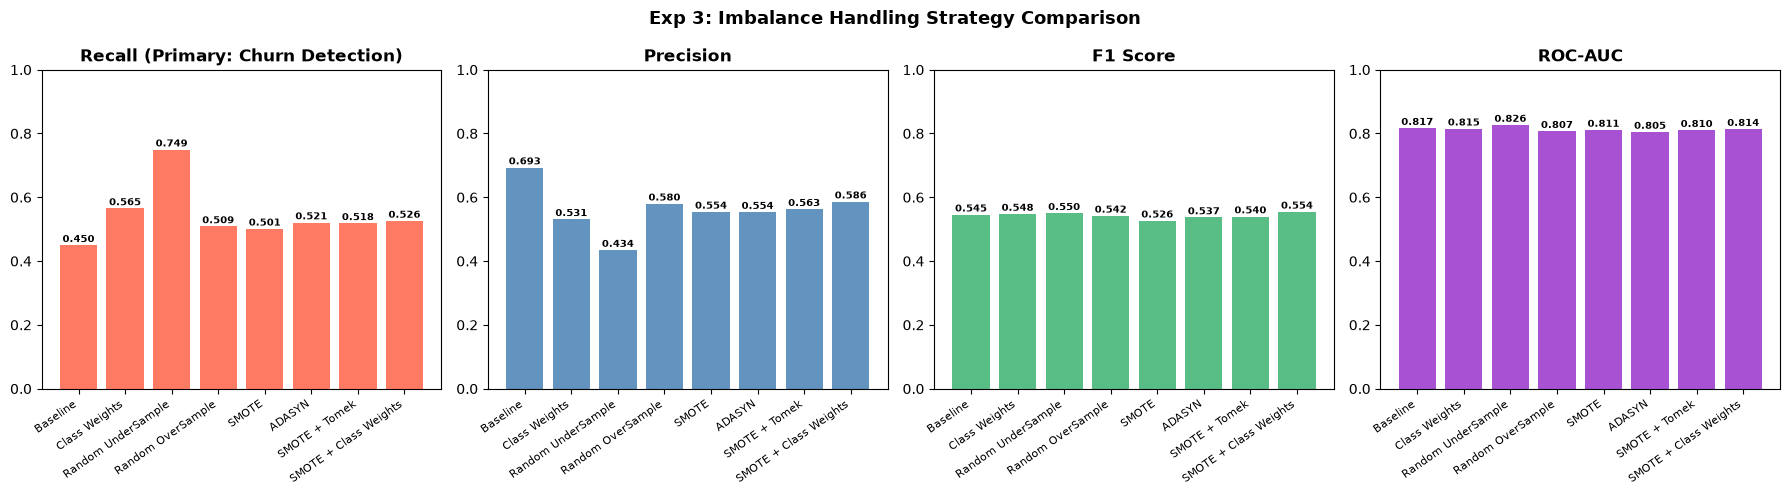

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
strategies = list(all_metrics.keys())
metrics_to_plot = ['test_recall', 'test_precision', 'test_f1', 'test_roc_auc']
titles = ['Recall (Primary: Churn Detection)', 'Precision', 'F1 Score', 'ROC-AUC']
colors = ['tomato', 'steelblue', 'mediumseagreen', 'darkorchid']
for ax, metric, title, color in zip(axes, metrics_to_plot, titles, colors):
    vals = [all_metrics[s][metric] for s in strategies]
    bars = ax.bar(range(len(strategies)), vals, color=color, alpha=0.85)
    ax.set_xticks(range(len(strategies)))
    ax.set_xticklabels([s.split(' - ')[1] for s in strategies], rotation=35, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.0)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{v:.3f}', ha='center', fontsize=7, fontweight='bold')
plt.suptitle('Exp 3: Imbalance Handling Strategy Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Confusion Matrices -- All 8 Strategies

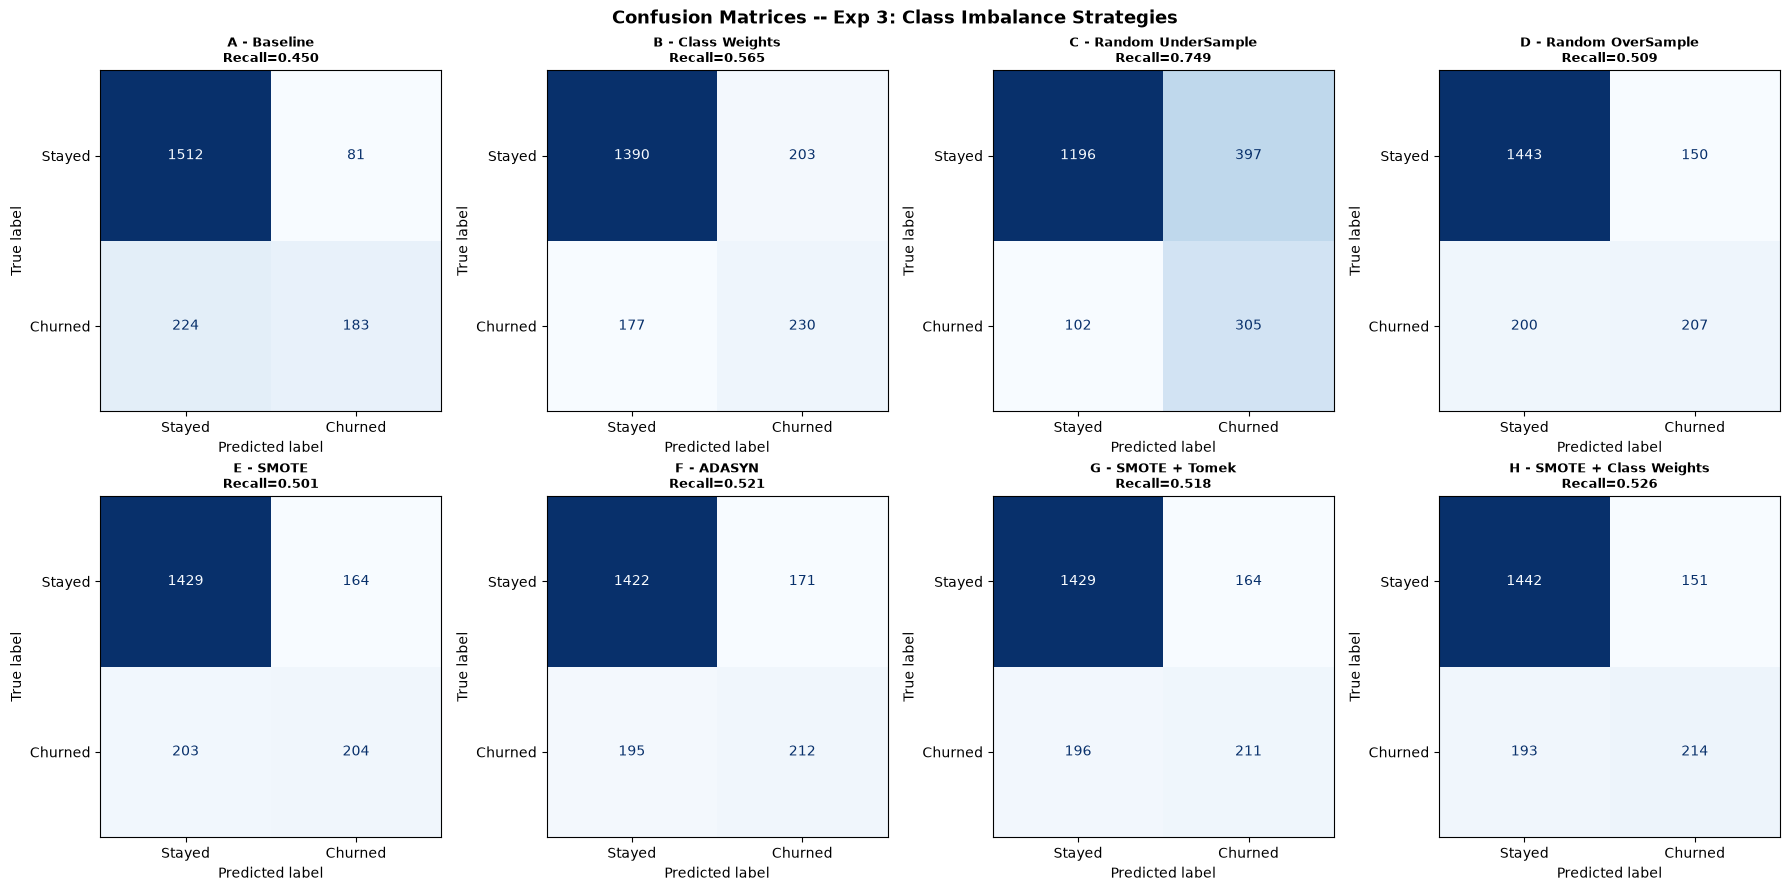

In [ ]:
all_preds = {
    'A - Baseline'             : pred_a,
    'B - Class Weights'        : pred_b,
    'C - Random UnderSample'   : pred_c,
    'D - Random OverSample'    : pred_d,
    'E - SMOTE'                : pred_e,
    'F - ADASYN'               : pred_f,
    'G - SMOTE + Tomek'        : pred_g,
    'H - SMOTE + Class Weights': pred_h,
}
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (name, preds) in zip(axes.flat, all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    tp = cm[1, 1]
    fn = cm[1, 0]
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    ax.set_title(f'{name}\nRecall={recall_val:.3f}', fontsize=9, fontweight='bold')
plt.suptitle('Confusion Matrices -- Exp 3: Class Imbalance Strategies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cross-Validation Recall Distribution

In [ ]:
print('=== CV Summary (5-Fold Stratified) ===')
all_cv = {
    'A - Baseline'             : results_a,
    'B - Class Weights'        : results_b,
    'C - Random UnderSample'   : results_c,
    'D - Random OverSample'    : results_d,
    'E - SMOTE'                : results_e,
    'F - ADASYN'               : results_f,
    'G - SMOTE + Tomek'        : results_g,
    'H - SMOTE + Class Weights': results_h,
}
for name, res in all_cv.items():
    print(f"  {name}")
    print(f"    CV Recall  : {res['test_recall'].mean():.4f} +/- {res['test_recall'].std():.4f}")
    print(f"    CV F1      : {res['test_f1'].mean():.4f} +/- {res['test_f1'].std():.4f}")
    print(f"    CV ROC-AUC : {res['test_roc_auc'].mean():.4f} +/- {res['test_roc_auc'].std():.4f}")
    print()

=== CV Summary (5-Fold Stratified) ===
  A - Baseline
    CV Recall  : 0.4307 +/- 0.0245
    CV F1      : 0.5220 +/- 0.0247
    CV ROC-AUC : 0.8152 +/- 0.0182

  B - Class Weights
    CV Recall  : 0.5521 +/- 0.0373
    CV F1      : 0.5463 +/- 0.0240
    CV ROC-AUC : 0.8163 +/- 0.0187

  C - Random UnderSample
    CV Recall  : 0.7110 +/- 0.0355
    CV F1      : 0.5324 +/- 0.0132
    CV ROC-AUC : 0.8169 +/- 0.0156

  D - Random OverSample
    CV Recall  : 0.5037 +/- 0.0377
    CV F1      : 0.5387 +/- 0.0284
    CV ROC-AUC : 0.8139 +/- 0.0165

  E - SMOTE
    CV Recall  : 0.5061 +/- 0.0243
    CV F1      : 0.5367 +/- 0.0145
    CV ROC-AUC : 0.8116 +/- 0.0127

  F - ADASYN
    CV Recall  : 0.5190 +/- 0.0306
    CV F1      : 0.5368 +/- 0.0186
    CV ROC-AUC : 0.8115 +/- 0.0167

  G - SMOTE + Tomek
    CV Recall  : 0.5245 +/- 0.0354
    CV F1      : 0.5487 +/- 0.0259
    CV ROC-AUC : 0.8139 +/- 0.0172

  H - SMOTE + Class Weights
    CV Recall  : 0.5178 +/- 0.0372
    CV F1      : 0.5415 +/-

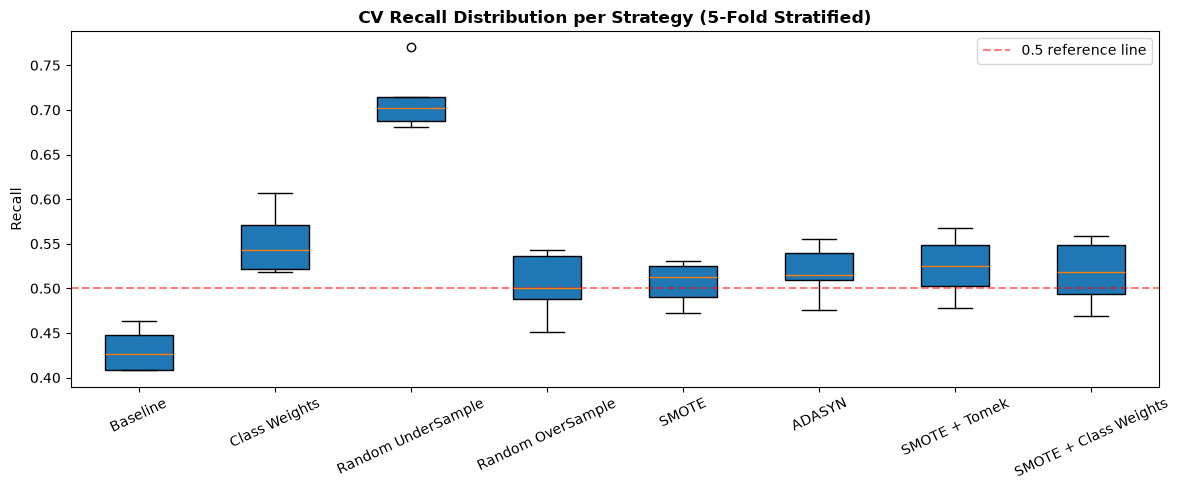

In [ ]:
cv_recall_data = {name.split(' - ')[1]: res['test_recall'].values for name, res in all_cv.items()}
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(list(cv_recall_data.values()), patch_artist=True)
ax.set_xticks(range(1, len(cv_recall_data) + 1))
ax.set_xticklabels(list(cv_recall_data.keys()), rotation=25)
ax.set_title('CV Recall Distribution per Strategy (5-Fold Stratified)', fontweight='bold')
ax.set_ylabel('Recall')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 reference line')
ax.legend()
plt.tight_layout()
plt.show()

## Business Impact Analysis

ROI simulation based on `CLASS_IMBALANCE_SOLUTION_GUIDE.md` assumptions:
- Actual churners in test set: ~407 customers  
- Customer Lifetime Value (LTV): $500  
- Retention intervention cost: $50 / contact  
- Retention conversion success rate: 40%

In [ ]:
ltv = 500
campaign_cost = 50
retention_rate = 0.40
actual_churners = int(y_test.sum())
print('=== Business ROI Simulation ===')
print(f'Actual churners in test set: {actual_churners}')
rows = []
for name, preds in all_preds.items():
    tp = int(((preds == 1) & (y_test == 1)).sum())
    fp = int(((preds == 1) & (y_test == 0)).sum())
    fn = int(((preds == 0) & (y_test == 1)).sum())
    contacts = tp + fp
    revenue_saved = tp * retention_rate * ltv
    campaign_spend = contacts * campaign_cost
    net_benefit = revenue_saved - campaign_spend
    rows.append({
        'Strategy': name, 'TP (Caught)': tp, 'FP (Alarms)': fp, 'FN (Missed)': fn,
        'Contacts': contacts, 'Revenue Saved': int(revenue_saved),
        'Campaign Cost': int(campaign_spend), 'Net Benefit': int(net_benefit),
    })
roi_df = pd.DataFrame(rows).sort_values('Net Benefit', ascending=False)
roi_df

=== Business ROI Simulation ===
Actual churners in test set: 407


,Strategy,TP (Caught),FP (Alarms),FN (Missed),Contacts,Revenue Saved,Campaign Cost,Net Benefit
2,C - Random UnderSample,305,397,102,702,61000,35100,25900
7,H - SMOTE + Class Weights,214,151,193,365,42800,18250,24550
1,B - Class Weights,230,203,177,433,46000,21650,24350
3,D - Random OverSample,207,150,200,357,41400,17850,23550
6,G - SMOTE + Tomek,211,164,196,375,42200,18750,23450
0,A - Baseline,183,81,224,264,36600,13200,23400
5,F - ADASYN,212,171,195,383,42400,19150,23250
4,E - SMOTE,204,164,203,368,40800,18400,22400


## Final Recommendation & Summary

In [ ]:
final_summary = pd.DataFrame(all_metrics).T[
    ['test_recall', 'test_precision', 'test_f1', 'test_roc_auc', 'test_accuracy',
     'cv_mean_recall', 'cv_mean_f1', 'cv_mean_roc_auc']
].round(4)
final_summary = final_summary.sort_values('cv_mean_recall', ascending=False)
print('=== FINAL SUMMARY -- Ranked by CV Mean Recall ===')
print(final_summary.to_string())
print()
winner = final_summary.index[0]
print(f'Winning strategy (highest CV Recall): {winner}')
print()
print('>>> Winning strategy configuration ready for 06_Churn_Model_Selection.ipynb')

=== FINAL SUMMARY -- Ranked by CV Mean Recall ===
                           test_recall  test_precision  test_f1  test_roc_auc  test_accuracy  cv_mean_recall  cv_mean_f1  cv_mean_roc_auc
C - Random UnderSample          0.7494          0.4345   0.5500        0.8265         0.7505          0.7110      0.5324           0.8169
B - Class Weights               0.5651          0.5312   0.5476        0.8150         0.8100          0.5521      0.5463           0.8163
G - SMOTE + Tomek               0.5184          0.5627   0.5396        0.8104         0.8200          0.5245      0.5487           0.8139
F - ADASYN                      0.5209          0.5535   0.5367        0.8047         0.8170          0.5190      0.5368           0.8115
H - SMOTE + Class Weights       0.5258          0.5863   0.5544        0.8136         0.8280          0.5178      0.5415           0.8127
E - SMOTE                       0.5012          0.5543   0.5265        0.8110         0.8165          0.5061      0.5367  

In [ ]:
best_strat_metrics = all_metrics[winner]
try:
    with mlflow.start_run(run_name='WINNER - Best Imbalance Strategy'):
        mlflow.log_param('winning_strategy',   winner)
        mlflow.log_param('imputer',            'KNNImputer(n_neighbors=10)')
        mlflow.log_metric('best_cv_recall',    best_strat_metrics['cv_mean_recall'])
        mlflow.log_metric('best_cv_f1',        best_strat_metrics['cv_mean_f1'])
        mlflow.log_metric('best_cv_roc_auc',   best_strat_metrics['cv_mean_roc_auc'])
        mlflow.log_metric('best_test_recall',  best_strat_metrics['test_recall'])
        mlflow.log_metric('best_test_f1',      best_strat_metrics['test_f1'])
        mlflow.log_metric('best_test_roc_auc', best_strat_metrics['test_roc_auc'])
    print('Final recommendation logged to MLflow.')
except Exception as e:
    print(f'[MLflow Notice] {e}')

🏃 View run WINNER - Best Imbalance Strategy at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2/runs/b3806a3e93c84f92b49c6f7dd2c0b341
🧪 View experiment at: https://dagshub.com/Ankitkumar1141/Churn-modelling.mlflow/#/experiments/2
Final recommendation logged to MLflow.
